# Activity State — Kinematic Axis (HSI 1.3)

Deterministic rulepack producing the `activity_state` categorical reading for the `kinematic` domain (RFC-HSI-0010).

## Overview
- Objective: classify activity state from inertial signals using orientation-invariant features.
- Sampling: 50 Hz. Window: 2.56 s (128 samples), 50% overlap.
- Feature domain: magnitude of the body-acceleration vector (orientation-invariant). Gyroscope magnitude for the cycling branch only.
- Classifier: deterministic rulepack (fixed thresholds; no training).
- Datasets: UCI-HAR (orientation test), MotionSense (rule derivation and confidence), HHAR (cross-dataset validation and cycling).
- Classes modeled: sedentary, walking, running, cycling. Standing folded into sedentary (posture handled by the postural_state axis). Vigorous unmodeled.
- Output: HSI 1.3 categorical reading, model_id `rulepack://activity_state_v1`.

## 1. Setup and configuration
Imports and all constants in one place.

In [ ]:
import os, glob, json, zipfile
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.spatial.transform import Rotation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


mpl.rcParams.update({
    "figure.figsize": (7.0, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "font.size": 11,
    "legend.fontsize": 10,
})
np.random.seed(0)

In [ ]:
# Sampling and windowing
SAMPLE_RATE = 50                 # Hz
WINDOW = 128                     # samples per window (2.56 s)
STEP = 64                        # 50% overlap

# Rulepack decision thresholds (derived on MotionSense; magnitude features in g)
T_STILL = 0.10                   # movement (std of |accel|) below this -> still / sedentary
T_RUN   = 1.00                   # energy (mean of |accel|) above this while moving -> running
BAND_LO = 0.77                   # lower edge of the walk/run energy overlap band
BAND_HI = 1.07                   # upper edge of the walk/run energy overlap band
CAD_RUN = 1.20                   # PROVISIONAL: cadence (Hz) splitting walking/running in the band (placement-specific)
T_GYRO  = 0.18                   # PROVISIONAL: gyro energy (rad/s) above this in the still region -> cycling (waist-derived)
UCI_MOVE_THR = 0.05              # still/moving split for the UCI-HAR orientation test (UCI units)

# Gravity separation for raw accelerometer (HHAR)
GRAVITY_CUTOFF = 0.3             # Hz, Butterworth low-pass cutoff to estimate gravity
G = 9.81                         # m/s^2, body-accel divisor to convert to g

# Held-out splits (subject-independent)
MS_TEST_SUBJ = {19, 20, 21, 22, 23, 24}
CYC_TEST_USERS = {"g", "h", "i"}

# HSI categories and figure palette
HSI_CATEGORIES = ["sedentary", "standing", "walking", "running", "cycling", "vigorous"]
STATE_COLORS = {"sedentary": "#4C72B0", "standing": "#55A868", "walking": "#DD8452",
                "running": "#C44E52", "cycling": "#8172B3"}

# Dataset paths
ROOT = "/home/voare/Documents/Synheart/Kinematics/Dataset"
UCI_BASE = ROOT + "/UCI HAR Dataset"
MS_ROOT  = ROOT + "/MotionSense/A_DeviceMotion_data/A_DeviceMotion_data"
HHAR_ZIP = ROOT + "/HHAR/Activity recognition exp.zip"

## 2. Feature extraction
Magnitude-domain features: movement (std), energy (mean), cadence and regularity (autocorrelation).

In [ ]:
def magnitude(x, y, z):
    """Vector magnitude sqrt(x^2 + y^2 + z^2); orientation-invariant."""
    return np.sqrt(x**2 + y**2 + z**2)

def window_signal(a, n=WINDOW, step=STEP):
    """Split a 1-D signal into overlapping windows -> array (n_windows, n)."""
    return np.stack([a[i:i+n] for i in range(0, len(a) - n + 1, step)]) if len(a) >= n else np.empty((0, n))

def reg_cad(w):
    """Regularity (strongest autocorrelation peak, 0..1) and cadence (Hz) of one window."""
    w = w - w.mean()
    ac = np.correlate(w, w, mode="full")[len(w) - 1:]
    if ac[0] == 0:
        return 0.0, np.nan
    ac = ac / ac[0]
    seg = ac[10:64]
    k = 10 + int(np.argmax(seg))
    return float(seg.max()), SAMPLE_RATE / k

## 3. Orientation-invariance test
Magnitude features are invariant to device rotation; per-axis features are not. UCI-HAR.

In [ ]:
def uci_load(split):
    """Load UCI-HAR inertial signals and 3-state labels for one split."""
    names = pd.read_csv(UCI_BASE + "/activity_labels.txt", sep=r"\s+", header=None, index_col=0)[1]
    path = f"{UCI_BASE}/{split}/Inertial Signals"
    channels = ["body_acc_x", "body_acc_y", "body_acc_z", "body_gyro_x", "body_gyro_y", "body_gyro_z",
                "total_acc_x", "total_acc_y", "total_acc_z"]
    sig = {c: pd.read_csv(f"{path}/{c}_{split}.txt", sep=r"\s+", header=None).to_numpy() for c in channels}
    label = pd.read_csv(f"{UCI_BASE}/{split}/y_{split}.txt", header=None)[0].map(names)
    state = label.replace({"SITTING": "sedentary", "LAYING": "sedentary", "STANDING": "standing",
                           "WALKING": "walking", "WALKING_UPSTAIRS": "walking", "WALKING_DOWNSTAIRS": "walking"})
    return sig, state.to_numpy()

def uci_rule(sig):
    """Still/moving rule on the orientation-invariant acceleration magnitude (UCI units)."""
    move = magnitude(sig["body_acc_x"], sig["body_acc_y"], sig["body_acc_z"]).std(axis=1)
    return np.where(move > UCI_MOVE_THR, "walking", "sedentary")

def feats_coupled(sig):
    """Orientation-dependent per-axis features (contrast baseline)."""
    return np.column_stack([sig["total_acc_x"].mean(1), sig["total_acc_y"].mean(1), sig["total_acc_z"].mean(1),
                            sig["body_acc_x"].std(1), sig["body_acc_y"].std(1), sig["body_acc_z"].std(1)])

def rotate_all(sig, seed=0):
    """Apply an independent random 3D rotation to every window."""
    rng = np.random.default_rng(seed)
    n = sig["body_acc_x"].shape[0]
    out = {k: np.empty_like(v) for k, v in sig.items()}
    triples = [("body_acc_x", "body_acc_y", "body_acc_z"),
               ("body_gyro_x", "body_gyro_y", "body_gyro_z"),
               ("total_acc_x", "total_acc_y", "total_acc_z")]
    for i in range(n):
        R = Rotation.random(random_state=rng).as_matrix()
        for t in triples:
            r = R @ np.stack([sig[t[0]][i], sig[t[1]][i], sig[t[2]][i]])
            for j, name in enumerate(t):
                out[name][i] = r[j]
    return out

uci_tr, uci_y_tr = uci_load("train")
uci_te, uci_y_te = uci_load("test")
print("UCI-HAR states:", sorted(set(uci_y_tr)))

UCI-HAR states: ['sedentary', 'standing', 'walking']


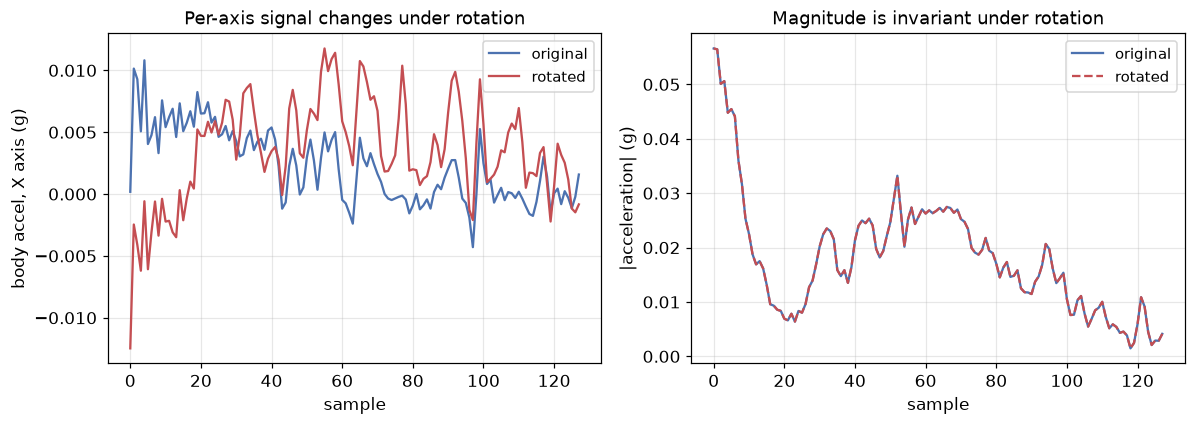

max magnitude difference: 1.39e-17


In [ ]:
# One body-accel window before and after a random 3D rotation.
i = 0
xyz = np.stack([uci_tr["body_acc_x"][i], uci_tr["body_acc_y"][i], uci_tr["body_acc_z"][i]])
R = Rotation.random(random_state=1).as_matrix()
xyz_rot = R @ xyz
mag_before, mag_after = magnitude(*xyz), magnitude(*xyz_rot)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(xyz[0], color="#4C72B0", label="original")
axes[0].plot(xyz_rot[0], color="#C44E52", label="rotated")
axes[0].set_title("Per-axis signal changes under rotation")
axes[0].set_xlabel("sample"); axes[0].set_ylabel("body accel, X axis (g)"); axes[0].legend()
axes[1].plot(mag_before, color="#4C72B0", label="original")
axes[1].plot(mag_after, "--", color="#C44E52", label="rotated")
axes[1].set_title("Magnitude is invariant under rotation")
axes[1].set_xlabel("sample"); axes[1].set_ylabel("|acceleration| (g)"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"max magnitude difference: {np.abs(mag_before - mag_after).max():.2e}")

                   original pose  rotated pose
magnitude rule              80.7          80.7
per-axis features           93.2          54.8


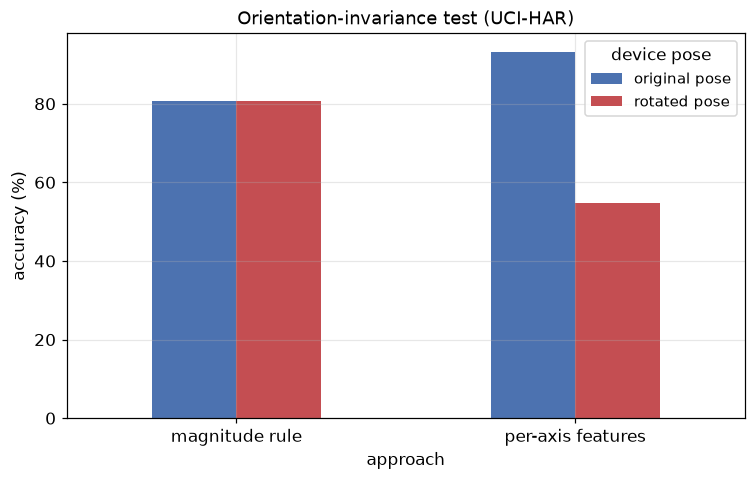

In [ ]:
# Accuracy under original vs rotated device pose: invariant rule vs per-axis features.
uci_te_rot = rotate_all(uci_te, seed=0)
clf = RandomForestClassifier(n_estimators=100, random_state=0).fit(feats_coupled(uci_tr), uci_y_tr)
orient = pd.DataFrame(
    {"magnitude rule": [accuracy_score(uci_y_te, uci_rule(uci_te)) * 100,
                        accuracy_score(uci_y_te, uci_rule(uci_te_rot)) * 100],
     "per-axis features": [accuracy_score(uci_y_te, clf.predict(feats_coupled(uci_te))) * 100,
                           accuracy_score(uci_y_te, clf.predict(feats_coupled(uci_te_rot))) * 100]},
    index=["original pose", "rotated pose"]).T
print(orient.round(1).to_string())

ax = orient.plot(kind="bar", color=["#4C72B0", "#C44E52"])
ax.set_ylabel("accuracy (%)"); ax.set_xlabel("approach")
ax.set_title("Orientation-invariance test (UCI-HAR)")
ax.set_xticklabels(orient.index, rotation=0)
ax.legend(title="device pose")
plt.tight_layout(); plt.show()

## 4. MotionSense: rule and evaluation
Thresholds derived on MotionSense; subject-independent split; full accel rule with cadence tiebreaker.

In [ ]:
MS_LABELS = {"sit": "sedentary", "std": "standing", "wlk": "walking", "jog": "running"}  # stairs (dws/ups) excluded

ms_rows = []
for folder in sorted(os.listdir(MS_ROOT)):
    code_ = folder.split("_")[0]
    if code_ not in MS_LABELS:
        continue
    for f in glob.glob(f"{MS_ROOT}/{folder}/sub_*.csv"):
        subj = int(os.path.basename(f)[4:-4])
        d = pd.read_csv(f)
        mag = magnitude(d["userAcceleration.x"], d["userAcceleration.y"], d["userAcceleration.z"]).to_numpy()
        for w in window_signal(mag):
            _, cad = reg_cad(w)
            ms_rows.append((MS_LABELS[code_], subj, w.std(), w.mean(), cad))
ms = pd.DataFrame(ms_rows, columns=["state", "subj", "movement", "mean_mag", "cad"])
print(f"MotionSense windows: {len(ms)}")
print(ms["state"].value_counts().to_string())

MotionSense windows: 17237
state
walking      5275
sedentary    5221
standing     4716
running      2025


In [ ]:
ms_tr = ms[~ms["subj"].isin(MS_TEST_SUBJ)]
ms_te = ms[ms["subj"].isin(MS_TEST_SUBJ)]
print(f"train windows {len(ms_tr)} | test windows {len(ms_te)} | held-out subjects {sorted(MS_TEST_SUBJ)}")
print()
print("median feature per state (train):")
print(ms_tr.groupby("state")[["movement", "mean_mag"]].median().round(3).to_string())

train windows 12896 | test windows 4341 | held-out subjects [19, 20, 21, 22, 23, 24]

median feature per state (train):
           movement  mean_mag
state                        
running       0.789     1.517
sedentary     0.004     0.018
standing      0.012     0.041
walking       0.419     0.709


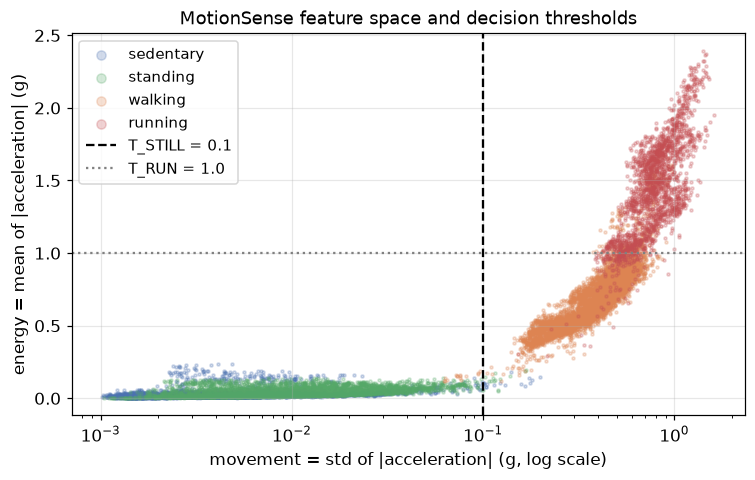

In [ ]:
# Feature space with the still and run thresholds.
for s in ["sedentary", "standing", "walking", "running"]:
    sub = ms[ms["state"] == s]
    plt.scatter(sub["movement"], sub["mean_mag"], s=4, alpha=0.25, color=STATE_COLORS[s], label=s)
plt.axvline(T_STILL, ls="--", color="black", label=f"T_STILL = {T_STILL}")
plt.axhline(T_RUN, ls=":", color="gray", label=f"T_RUN = {T_RUN}")
plt.xscale("log")
plt.xlabel("movement = std of |acceleration| (g, log scale)")
plt.ylabel("energy = mean of |acceleration| (g)")
plt.title("MotionSense feature space and decision thresholds")
plt.legend(markerscale=3)
plt.tight_layout(); plt.show()

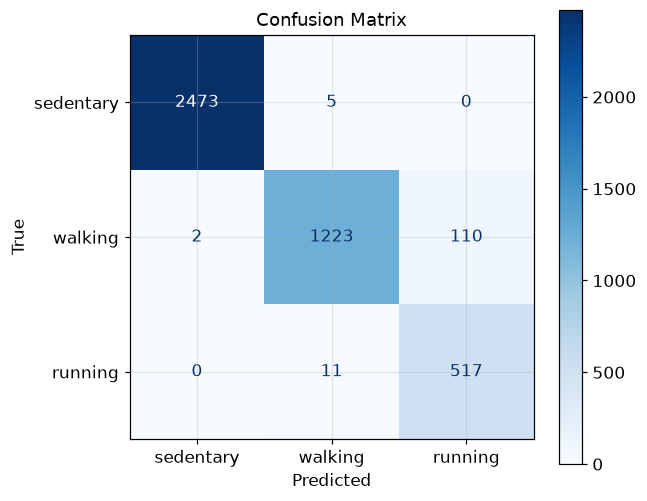

In [ ]:


def ms_base_rule(df):
    """Energy rule: still / walking / running from movement and energy."""
    return np.where(df["movement"] < T_STILL, "sedentary",
           np.where(df["mean_mag"] < T_RUN, "walking", "running"))

def activity_rule(df):
    """Full accel rule: energy rule with a cadence tiebreaker inside the walk/run overlap band."""
    base = ms_base_rule(df)
    in_band = (df["mean_mag"] >= BAND_LO) & (df["mean_mag"] <= BAND_HI) & (df["movement"] >= T_STILL)
    cad_call = np.where(df["cad"] >= CAD_RUN, "running", "walking")
    return np.where(in_band, cad_call, base)

def confusion(true, pred, index, columns):
    """Labeled confusion matrix (true rows, predicted columns)."""
    return (pd.crosstab(
                pd.Series(true, name="true"),
                pd.Series(pred, name="pred")
            )
            .reindex(index=index, columns=columns)
            .fillna(0)
            .astype(int))

# Ground truth and predictions
ms_true = ms_te["state"].to_numpy()
ms_true_folded = pd.Series(ms_true).replace({"standing": "sedentary"}).to_numpy()
ms_pred = activity_rule(ms_te)

labels = ["sedentary", "walking", "running"]

cm = confusion(
    ms_true_folded,
    ms_pred,
    labels,
    labels
)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm.values,
    display_labels=labels
)

disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

## 5. Confidence and calibration
Confidence as normalized distance to the deciding boundary (per-class references); reliability table and ECE.

In [ ]:
_sed = ms_tr[ms_tr["state"] == "sedentary"]
_wlk = ms_tr[ms_tr["state"] == "walking"]
_run = ms_tr[ms_tr["state"] == "running"]
_in_band = lambda g: g[(g["mean_mag"] >= BAND_LO) & (g["mean_mag"] <= BAND_HI)]
REF_MOVE_SED = _sed["movement"].std()
REF_MOVE_WLK = _wlk["movement"].std()
REF_EN_WLK   = _wlk["mean_mag"].std()
REF_EN_RUN   = _run["mean_mag"].std()
REF_CAD_WLK  = _in_band(_wlk)["cad"].std()
REF_CAD_RUN  = _in_band(_run)["cad"].std()

def confidence(df, pred):
    """Confidence in [0.5, 1.0]: distance to the deciding boundary in per-class train-stds."""
    mov, en, cad = df["movement"].to_numpy(), df["mean_mag"].to_numpy(), df["cad"].to_numpy()
    in_band = (en >= BAND_LO) & (en <= BAND_HI) & (mov >= T_STILL)
    m_sed = (T_STILL - mov) / REF_MOVE_SED
    m_wlk = np.minimum((mov - T_STILL) / REF_MOVE_WLK, (T_RUN - en) / REF_EN_WLK)
    m_run = (en - T_RUN) / REF_EN_RUN
    m_cadw = (CAD_RUN - cad) / REF_CAD_WLK
    m_cadr = (cad - CAD_RUN) / REF_CAD_RUN
    margin = np.where(pred == "sedentary", m_sed,
             np.where(in_band, np.where(pred == "running", m_cadr, m_cadw),
             np.where(pred == "running", m_run, m_wlk)))
    return 0.5 + 0.5 * np.clip(margin, 0, 1)

def reliability(conf, correct, n_bins=5):
    """Reliability table (mean confidence vs accuracy per bin) and expected calibration error."""
    edges = np.linspace(0.5, 1.0, n_bins + 1)
    records, ece, total = [], 0.0, len(conf)
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf >= lo) & (conf <= hi if hi == 1.0 else conf < hi)
        if m.sum() == 0:
            continue
        c, a = conf[m].mean(), correct[m].mean()
        ece += m.sum() / total * abs(a - c)
        records.append((f"[{lo:.1f},{hi:.1f})", int(m.sum()), round(float(c), 3), round(float(a), 3)))
    return pd.DataFrame(records, columns=["bin", "n", "mean_conf", "accuracy"]), ece

ms_conf = confidence(ms_te, ms_pred)
ms_correct = (ms_pred == ms_true_folded).astype(float)
ms_rel, ms_ece = reliability(ms_conf, ms_correct)
print("Reliability (held-out subjects):")
print(ms_rel.to_string(index=False))
print()
print(f"ECE = {ms_ece:.3f} | accuracy = {ms_correct.mean():.3f}")

Reliability (held-out subjects):
      bin    n  mean_conf  accuracy
[0.5,0.6)    4      0.568     0.500
[0.6,0.7)  103      0.643     0.825
[0.7,0.8)   46      0.748     0.565
[0.8,0.9)  130      0.856     0.915
[0.9,1.0) 4058      0.998     0.981

ECE = 0.024 | accuracy = 0.971


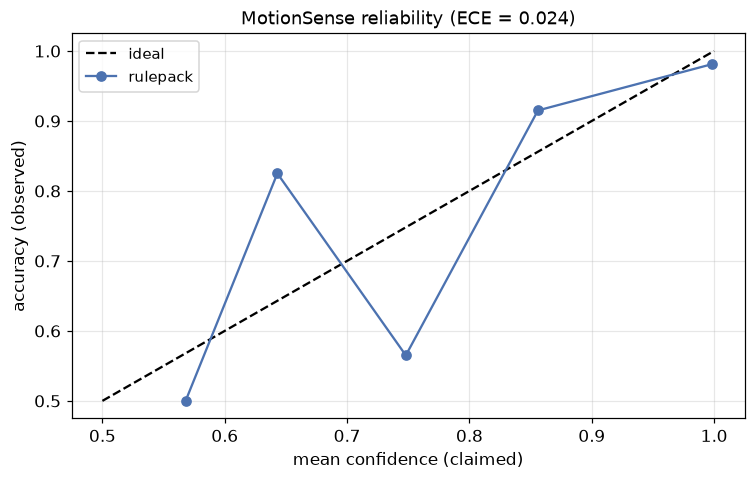

In [ ]:
plt.plot([0.5, 1.0], [0.5, 1.0], "k--", label="ideal")
plt.plot(ms_rel["mean_conf"], ms_rel["accuracy"], "o-", color="#4C72B0", label="rulepack")
plt.xlabel("mean confidence (claimed)")
plt.ylabel("accuracy (observed)")
plt.title(f"MotionSense reliability (ECE = {ms_ece:.3f})")
plt.legend()
plt.tight_layout(); plt.show()

## 6. HSI emission
HSI 1.3 categorical reading for activity_state (single-modality: no modalities_used / confidence_breakdown).

In [ ]:
def hsi_reading(label, conf):
    """HSI 1.3 categorical reading for kinematic activity_state (RFC-HSI-0010)."""
    return {"name": "activity_state", "score": None, "label": label, "categories": HSI_CATEGORIES,
            "confidence": round(float(conf), 3), "direction": "categorical",
            "inference_mode": "deterministic_rule", "model_id": "rulepack://activity_state_v1"}

ms_readings = [hsi_reading(l, c) for l, c in zip(ms_pred, ms_conf)]
print(f"readings emitted: {len(ms_readings)}")
print(json.dumps(ms_readings[0], indent=2))

readings emitted: 4341
{
  "name": "activity_state",
  "score": null,
  "label": "running",
  "categories": [
    "sedentary",
    "standing",
    "walking",
    "running",
    "cycling",
    "vigorous"
  ],
  "confidence": 1.0,
  "direction": "categorical",
  "inference_mode": "deterministic_rule",
  "model_id": "rulepack://activity_state_v1"
}


## 7. HHAR cross-dataset validation
Frozen rulepack applied to HHAR (waist, raw accel with gravity). No parameter re-derived. Loaders stream ~1.3 GB.

In [ ]:
HHAR_LABELS = {"sit": "sedentary", "stand": "sedentary", "walk": "walking", "bike": "cycling"}
BW_B, BW_A = butter(3, GRAVITY_CUTOFF / (SAMPLE_RATE / 2), btype="low")

def hhar_stream(member):
    """Stream one HHAR CSV from the zip, keeping mapped activities."""
    parts = []
    with zipfile.ZipFile(HHAR_ZIP).open(member) as fh:
        for chunk in pd.read_csv(fh, usecols=["Creation_Time", "x", "y", "z", "User", "Device", "gt"],
                                 chunksize=2_000_000, dtype={"x": "float32", "y": "float32", "z": "float32"}):
            parts.append(chunk[chunk["gt"].isin(HHAR_LABELS)])
    return pd.concat(parts, ignore_index=True)

def hhar_prep(d):
    """Sort by timestamp and drop duplicate timestamps -> (t seconds, xyz array)."""
    d = d.sort_values("Creation_Time")
    t = d["Creation_Time"].to_numpy() / 1e9
    keep = np.concatenate([[True], np.diff(t) > 0])
    t = t[keep]
    return t, np.vstack([d["x"].to_numpy()[keep], d["y"].to_numpy()[keep], d["z"].to_numpy()[keep]])

def hhar_accel_windows(t, xyz):
    """Resample to 50 Hz, remove gravity, convert to g, window -> (movement, energy, cadence)."""
    n = int((t[-1] - t[0]) * SAMPLE_RATE)
    if n < WINDOW:
        return []
    grid = t[0] + np.arange(n) / SAMPLE_RATE
    res = np.vstack([np.interp(grid, t, xyz[k]) for k in range(3)])
    body = (res - filtfilt(BW_B, BW_A, res, axis=1)) / G
    mag = magnitude(*body)
    out = []
    for i in range(0, n - WINDOW + 1, STEP):
        w = mag[i:i+WINDOW]
        _, cad = reg_cad(w)
        out.append((float(w.std()), float(w.mean()), cad))
    return out

raw_acc = hhar_stream("Activity recognition exp/Phones_accelerometer.csv")
h_rows = []
for (user, dev, gt), g in raw_acc.groupby(["User", "Device", "gt"]):
    t, xyz = hhar_prep(g)
    brk = np.where(np.diff(t) > 0.1)[0] + 1
    for s, e in zip(np.r_[0, brk], np.r_[brk, len(t)]):
        for mv, mm, cd in hhar_accel_windows(t[s:e], xyz[:, s:e]):
            h_rows.append((HHAR_LABELS[gt], user, mv, mm, cd))
H = pd.DataFrame(h_rows, columns=["state", "user", "movement", "mean_mag", "cad"])
print(f"HHAR accel windows: {len(H)}  {H['state'].value_counts().to_dict()}")

HHAR accel windows: 49761  {'sedentary': 24372, 'walking': 14256, 'cycling': 11133}


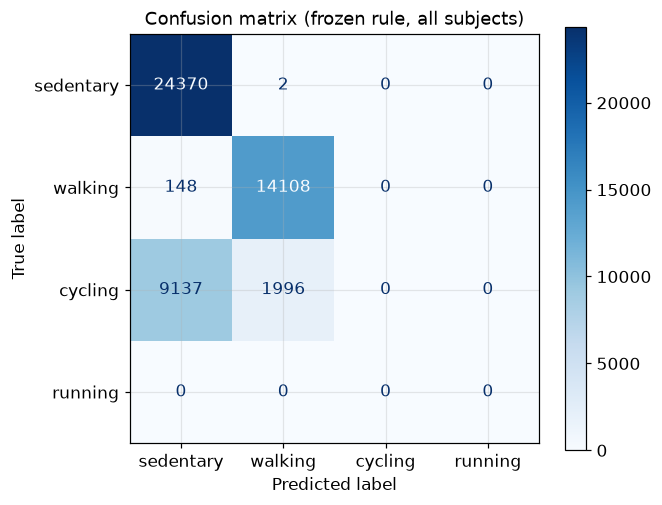


Shared-class metrics (sedentary, walking):
              precision    recall  f1-score   support

   sedentary      0.994     1.000     0.997     24372
     walking      1.000     0.990     0.995     14256

    accuracy                          0.996     38628
   macro avg      0.997     0.995     0.996     38628
weighted avg      0.996     0.996     0.996     38628

Reliability (shared classes):
      bin     n  mean_conf  accuracy
[0.5,0.6)  1215      0.569     0.975
[0.6,0.7)  3995      0.655     0.992
[0.7,0.8)  4707      0.748     0.997
[0.8,0.9)  2923      0.844     0.993
[0.9,1.0) 25788      0.997     0.998

ECE = 0.090 | accuracy = 0.996


In [ ]:
H["pred"] = activity_rule(H)
H["conf"] = confidence(H, H["pred"].to_numpy())

cm = confusion(H["state"], H["pred"], 
               ["sedentary", "walking", "cycling", "running"], 
               ["sedentary", "walking", "cycling", "running"])
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm.values, 
                              display_labels=["sedentary", "walking", "cycling", "running"])
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title("Confusion matrix (frozen rule, all subjects)")
plt.show()

hhar_shared = H[H["state"].isin(["sedentary", "walking"])]
print()
print("Shared-class metrics (sedentary, walking):")
print(classification_report(hhar_shared["state"], hhar_shared["pred"],
                            labels=["sedentary", "walking"], digits=3, zero_division=0))

hhar_correct = (hhar_shared["pred"].to_numpy() == hhar_shared["state"].to_numpy()).astype(float)
hhar_rel, hhar_ece = reliability(hhar_shared["conf"].to_numpy(), hhar_correct)
print("Reliability (shared classes):")
print(hhar_rel.to_string(index=False))
print()
print(f"ECE = {hhar_ece:.3f} | accuracy = {hhar_correct.mean():.3f}")

## 8. Cycling branch (gyroscope)
Gyroscope magnitude separates cycling from sedentary in the still region. Gyro used for the cycling branch only.

In [ ]:
raw_gyro = hhar_stream("Activity recognition exp/Phones_gyroscope.csv")

def near_gap(grid, t):
    """Distance from each grid point to the nearest real sample."""
    idx = np.clip(np.searchsorted(t, grid), 1, len(t) - 1)
    return np.minimum(grid - t[idx-1], t[idx] - grid)

gyro_groups = raw_gyro.groupby(["User", "Device", "gt"]).groups
c_rows = []
for key, idx_a in raw_acc.groupby(["User", "Device", "gt"]).groups.items():
    if key not in gyro_groups:
        continue
    ta, XA = hhar_prep(raw_acc.loc[idx_a])
    tg, XG = hhar_prep(raw_gyro.loc[gyro_groups[key]])
    if len(ta) < 10 or len(tg) < 10:
        continue
    t0, t1 = max(ta[0], tg[0]), min(ta[-1], tg[-1])
    if t1 - t0 < 2.56:
        continue
    n = int((t1 - t0) * SAMPLE_RATE)
    grid = t0 + np.arange(n) / SAMPLE_RATE
    Ar = np.vstack([np.interp(grid, ta, XA[k]) for k in range(3)])
    Gr = np.vstack([np.interp(grid, tg, XG[k]) for k in range(3)])
    valid = (near_gap(grid, ta) < 0.06) & (near_gap(grid, tg) < 0.06)
    for blk in np.split(np.arange(n), np.where(np.diff(valid.astype(int)) != 0)[0] + 1):
        if not valid[blk[0]] or len(blk) < WINDOW:
            continue
        s, e = blk[0], blk[-1] + 1
        body = (Ar[:, s:e] - filtfilt(BW_B, BW_A, Ar[:, s:e], axis=1)) / G
        amag = magnitude(*body)
        gmag = magnitude(*Gr[:, s:e])
        for i in range(0, (e - s) - WINDOW + 1, STEP):
            wa, wg = amag[i:i+WINDOW], gmag[i:i+WINDOW]
            reg, cad = reg_cad(wa)
            c_rows.append((HHAR_LABELS[key[2]], key[0], float(wa.std()), float(wa.mean()), reg, cad, float(wg.mean())))
C = pd.DataFrame(c_rows, columns=["state", "user", "movement", "mean_mag", "accel_reg", "cad", "gyro_energy"])
print(f"aligned accel+gyro windows: {len(C)}  {C['state'].value_counts().to_dict()}")
print()
print("median feature per state:")
print(C.groupby("state")[["movement", "accel_reg", "gyro_energy"]].median().round(3).to_string())

aligned accel+gyro windows: 33930  {'sedentary': 17128, 'walking': 9979, 'cycling': 6823}

median feature per state:
           movement  accel_reg  gyro_energy
state                                      
cycling       0.077      0.336        0.707
sedentary     0.003      0.197        0.023
walking       0.157      0.539        0.661


In [ ]:
c_tr = C[~C["user"].isin(CYC_TEST_USERS)]
c_te = C[C["user"].isin(CYC_TEST_USERS)]
low_tr = c_tr[c_tr["movement"] < T_STILL]
low_te = c_te[c_te["movement"] < T_STILL]

def cue_metrics(col):
    """Cycling precision/recall/F1 in the still region; threshold from the train gap midpoint."""
    s = low_tr[low_tr["state"] == "sedentary"][col]
    c = low_tr[low_tr["state"] == "cycling"][col]
    thr = round(float((s.quantile(.95) + c.quantile(.05)) / 2), 3)
    pred = np.where(low_te[col] > thr, "cycling", "sedentary")
    true = low_te["state"].to_numpy()
    tp = int(((pred == "cycling") & (true == "cycling")).sum())
    fp = int(((pred == "cycling") & (true != "cycling")).sum())
    fn = int(((pred != "cycling") & (true == "cycling")).sum())
    P = tp / (tp + fp) if tp + fp else 0.0
    R = tp / (tp + fn) if tp + fn else 0.0
    F = 2 * P * R / (P + R) if P + R else 0.0
    return (col, thr, round(P, 3), round(R, 3), round(F, 3))

cue_table = pd.DataFrame([cue_metrics("accel_reg"), cue_metrics("gyro_energy")],
                         columns=["cue", "threshold", "precision", "recall", "f1"])
print("Cycling cue comparison (held-out test users, still region):")
print(cue_table.to_string(index=False))

Cycling cue comparison (held-out test users, still region):
        cue  threshold  precision  recall    f1
  accel_reg      0.292      0.494   0.668 0.568
gyro_energy      0.180      0.891   0.947 0.918


## 9. Integrated rule and final metrics
Gyro cycling branch added to the frozen accel rule; evaluated on held-out HHAR subjects.

In [ ]:
REF_GYRO_CYC = low_tr[low_tr["state"] == "cycling"]["gyro_energy"].std()
REF_GYRO_SED = low_tr[low_tr["state"] == "sedentary"]["gyro_energy"].std()

def activity_rule_gyro(df):
    """Full rule with the gyro cycling branch (fires only in the still region)."""
    base = activity_rule(df)
    still = df["movement"] < T_STILL
    return np.where(still & (df["gyro_energy"] > T_GYRO), "cycling", base)

def confidence_gyro(df, pred):
    """Confidence including cycling and the gyro-aware sedentary boundary."""
    mov, gy = df["movement"].to_numpy(), df["gyro_energy"].to_numpy()
    out = confidence(df, pred).copy()
    still = mov < T_STILL
    conf_cyc = 0.5 + 0.5 * np.clip((gy - T_GYRO) / REF_GYRO_CYC, 0, 1)
    conf_sed = 0.5 + 0.5 * np.clip(np.minimum((T_STILL - mov) / REF_MOVE_SED, (T_GYRO - gy) / REF_GYRO_SED), 0, 1)
    out = np.where(pred == "cycling", conf_cyc, out)
    out = np.where((pred == "sedentary") & still, conf_sed, out)
    return out

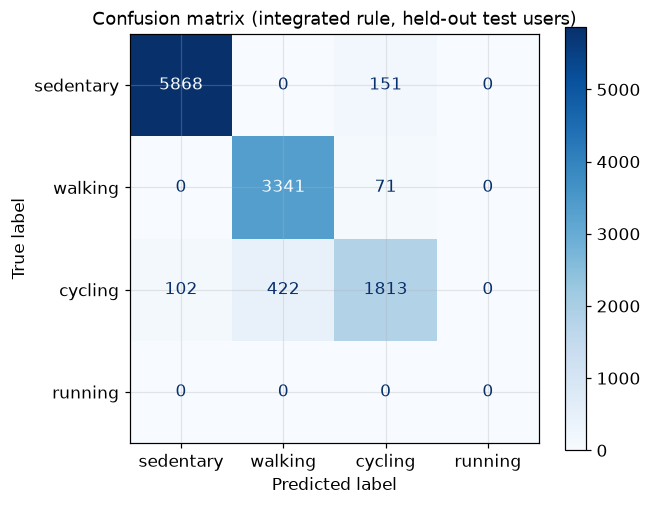


Per-class metrics:
              precision    recall  f1-score   support

   sedentary      0.983     0.975     0.979      6019
     walking      0.888     0.979     0.931      3412
     cycling      0.891     0.776     0.829      2337

    accuracy                          0.937     11768
   macro avg      0.921     0.910     0.913     11768
weighted avg      0.937     0.937     0.935     11768

Reliability:
      bin    n  mean_conf  accuracy
[0.5,0.6)  964      0.555     0.584
[0.6,0.7) 1446      0.653     0.907
[0.7,0.8) 1515      0.745     0.961
[0.8,0.9)  823      0.843     0.926
[0.9,1.0) 7020      0.997     0.987

ECE = 0.073 | accuracy = 0.937

Example cycling reading:
{"name": "activity_state", "score": null, "label": "cycling", "categories": ["sedentary", "standing", "walking", "running", "cycling", "vigorous"], "confidence": 1.0, "direction": "categorical", "inference_mode": "deterministic_rule", "model_id": "rulepack://activity_state_v1"}


In [ ]:
c_te = c_te.copy()
c_te["pred"] = activity_rule_gyro(c_te)
c_te["conf"] = confidence_gyro(c_te, c_te["pred"].to_numpy())

cm = confusion(c_te["state"], c_te["pred"], 
               ["sedentary", "walking", "cycling", "running"], 
               ["sedentary", "walking", "cycling", "running"])
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm.values, 
                              display_labels=["sedentary", "walking", "cycling", "running"])
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title("Confusion matrix (integrated rule, held-out test users)")
plt.show()
print()
print("Per-class metrics:")
print(classification_report(c_te["state"], c_te["pred"],
                            labels=["sedentary", "walking", "cycling"], digits=3, zero_division=0))

cyc_correct = (c_te["pred"].to_numpy() == c_te["state"].to_numpy()).astype(float)
cyc_rel, cyc_ece = reliability(c_te["conf"].to_numpy(), cyc_correct)
print("Reliability:")
print(cyc_rel.to_string(index=False))
print()
print(f"ECE = {cyc_ece:.3f} | accuracy = {cyc_correct.mean():.3f}")
print()
print("Example cycling reading:")
print(json.dumps(hsi_reading("cycling", float(c_te[c_te["pred"] == "cycling"]["conf"].iloc[0]))))

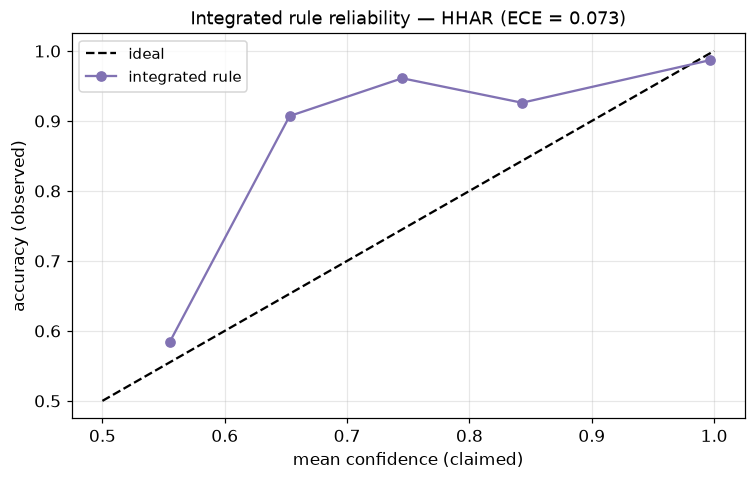

In [ ]:
plt.plot([0.5, 1.0], [0.5, 1.0], "k--", label="ideal")
plt.plot(cyc_rel["mean_conf"], cyc_rel["accuracy"], "o-", color="#8172B3", label="integrated rule")
plt.xlabel("mean confidence (claimed)")
plt.ylabel("accuracy (observed)")
plt.title(f"Integrated rule reliability — HHAR (ECE = {cyc_ece:.3f})")
plt.legend()
plt.tight_layout(); plt.show()

## 10. Summary

In [ ]:
ms_macro   = f1_score(ms_true_folded, ms_pred, average="macro")
hhar_macro = f1_score(hhar_shared["state"], hhar_shared["pred"], labels=["sedentary", "walking"], average="macro")
cyc_macro  = f1_score(c_te["state"], c_te["pred"], labels=["sedentary", "walking", "cycling"], average="macro")

summary = pd.DataFrame([
    ["MotionSense", "rule + confidence",    "sedentary/walking/running",  round(float(ms_correct.mean()), 3),   round(float(ms_macro), 3),   round(float(ms_ece), 3)],
    ["HHAR",        "frozen validation",    "sedentary/walking",          round(float(hhar_correct.mean()), 3), round(float(hhar_macro), 3), round(float(hhar_ece), 3)],
    ["HHAR",        "integrated + cycling", "sedentary/walking/cycling",  round(float(cyc_correct.mean()), 3),  round(float(cyc_macro), 3),  round(float(cyc_ece), 3)],
], columns=["dataset", "evaluation", "classes", "accuracy", "macro_f1", "ece"])
print(summary.to_string(index=False))

    dataset           evaluation                   classes  accuracy  macro_f1   ece
MotionSense    rule + confidence sedentary/walking/running     0.971     0.948 0.024
       HHAR    frozen validation         sedentary/walking     0.996     0.996 0.090
       HHAR integrated + cycling sedentary/walking/cycling     0.937     0.913 0.073


### Status
- Modeled and evaluated: sedentary, walking, running (MotionSense); cycling (HHAR, gyroscope).
- Standing folded into sedentary; standing/sitting separation is the postural_state axis.
- Provisional thresholds (single placement, not locked): `CAD_RUN` (walk/run cadence), `T_GYRO` (cycling).
- Unmodeled: vigorous; pocket cycling (HHAR cycling is waist-mounted).
- Output: HSI 1.3 categorical reading, `model_id rulepack://activity_state_v1`.